In [1]:
import optuna
import optuna.visualization as vis

STUDY_DB = "optuna_studies/optuna_study.db"
study = optuna.load_study(
    study_name="TBClassifier",
    storage=f"sqlite:///{STUDY_DB}"
)

In [2]:
print("Trials:", len(study.trials))
for t in study.trials:
    print(t.number, t.state)

Trials: 13
0 TrialState.COMPLETE
1 TrialState.COMPLETE
2 TrialState.COMPLETE
3 TrialState.COMPLETE
4 TrialState.RUNNING
5 TrialState.COMPLETE
6 TrialState.COMPLETE
7 TrialState.COMPLETE
8 TrialState.RUNNING
9 TrialState.COMPLETE
10 TrialState.COMPLETE
11 TrialState.COMPLETE
12 TrialState.RUNNING


In [8]:
best = study.best_trial

print(f"Best Trial: {best.number}")
print(f"  Value (mean): {best.value}")

fold_scores = best.user_attrs.get("fold_scores")
if fold_scores:
    print(f"  Fold scores: {fold_scores}")
    print(f"  Std: {np.std(fold_scores):.4f}")

print("  Params:")
for k, v in best.params.items():
    print(f"    {k}: {v}")

Best Trial: 9
  Value (mean): 0.9893312335014344
  Params:
    learning_rate: 0.00015514919971479425
    dropout: 0.21865652665653285
    weight_decay: 2.485139716480054e-05
    batch_size: 32


In [9]:
study.best_params

{'learning_rate': 7.394317384477617e-05,
 'dropout': 0.047065137600948326,
 'weight_decay': 2.1317951233959056e-05,
 'batch_size': 32}

In [7]:
study.trials_dataframe()

,number,value,datetime_start,datetime_complete,duration,params_batch_size,params_dropout,params_learning_rate,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,system_attrs_completed_rung_2,state
0,0,0.980739,2026-03-17 09:26:04.727827,2026-03-17 11:25:30.648169,0 days 01:59:25.920342,16,0.127087,0.000091,0.000118,0.957470,0.899374,NaN,COMPLETE
1,1,0.983484,2026-03-17 11:25:30.674860,2026-03-17 13:41:00.641024,0 days 02:15:29.966164,32,0.482109,0.000042,0.000005,0.978563,0.985250,NaN,COMPLETE
2,2,0.987116,2026-03-17 13:41:00.672358,2026-03-17 15:30:06.521419,0 days 01:49:05.849061,16,0.324459,0.000021,0.000119,NaN,NaN,NaN,COMPLETE
3,3,0.970199,2026-03-19 14:41:39.667918,2026-03-19 17:14:16.920604,0 days 02:32:37.252686,16,0.072737,0.000210,0.000003,0.976184,NaN,NaN,COMPLETE
4,4,NaN,2026-03-19 17:14:16.940498,NaT,NaT,32,0.259447,0.000187,0.000018,0.960261,NaN,NaN,RUNNING
5,5,0.988643,2026-03-23 10:49:11.325327,2026-03-23 13:52:15.004528,0 days 03:03:03.679201,32,0.047065,0.000074,0.000021,0.987489,NaN,NaN,COMPLETE
6,6,0.489173,2026-03-23 13:52:15.031425,2026-03-23 15:40:46.711412,0 days 01:48:31.679987,32,0.029530,0.000898,0.000801,0.857864,0.671200,0.968925,COMPLETE
7,7,NaN,2026-03-23 15:40:46.728532,NaT,NaT,32,0.223761,0.000010,0.000018,0.984110,NaN,NaN,RUNNING


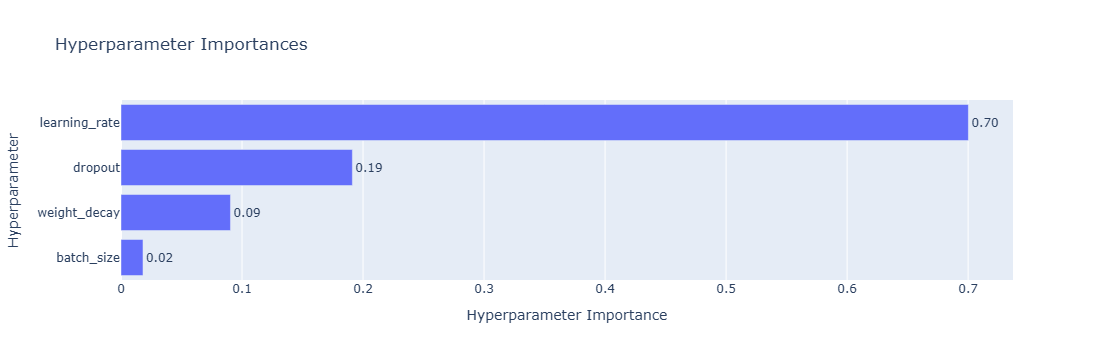

In [4]:
vis.plot_param_importances(study)

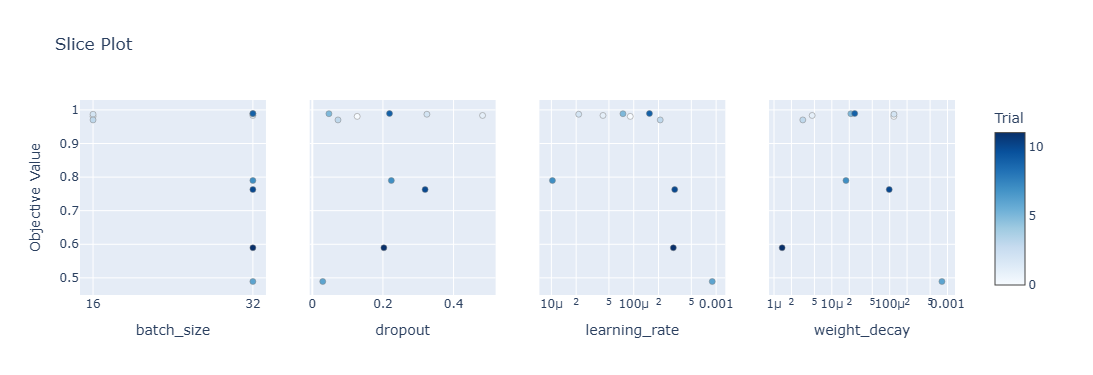

In [5]:
vis.plot_slice(study, params=["learning_rate", "dropout", "weight_decay", "batch_size"])

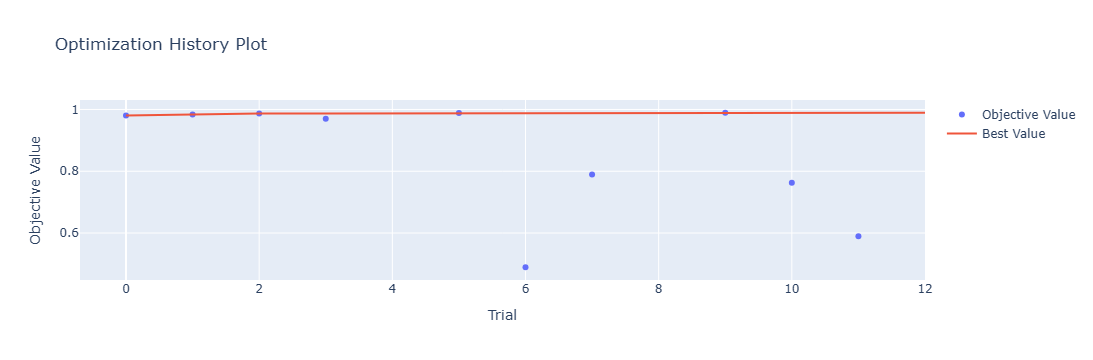

In [6]:
vis.plot_optimization_history(study)

In [23]:
from mlflow.tracking import MlflowClient
import mlflow
mlflow.set_tracking_uri("sqlite:///mlflow/tracking.db")
exp = mlflow.get_experiment_by_name("TBClassifier_tuning")
runs_df = mlflow.search_runs(experiment_ids=[exp.experiment_id])
runs_df.to_csv("mlflow_runs.csv", index=False)